# 파생변수 함수 및 생성 코드, 모델링까지 포함

# Import Library

In [ ]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.0/199.0 MB 5.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
import xgboost as xgb
import re
from sklearn.cluster import KMeans
from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load Processed-Data

In [ ]:
X = pd.read_csv("/content/train[5]X.csv")
test_X = pd.read_csv("/content/test[5]test_X.csv")
train = pd.read_csv("/content/train.csv")

In [ ]:
y_subclass = train['SUBCLASS']

# 파생변수 - 동의성 변이

In [ ]:
# 동의성 변이를 감지하는 함수
def is_synonymous_mutation(mutation):
    # 패턴: 동일한 문자로 변이된 경우 (ex: R123R)
    pattern = r'^([A-Z])\d+\1$'  # 동일한 아미노산으로 변이된 경우
    return bool(re.match(pattern, mutation))

# 동의성 변이의 개수를 세는 함수

In [ ]:
# 한 행의 동의성 변이 개수를 세는 함수
def count_synonymous_mutations(row, mutation_columns):
    count = 0  # 동의성 변이 개수 초기화
    for col in mutation_columns:
        mutation_string = row[col]
        if pd.isna(mutation_string):  # 변이가 없는 경우 건너뜀
            continue

        # 변이 문자열을 공백으로 분리하여 각각 처리
        mutations = mutation_string.split()
        count += sum(is_synonymous_mutation(mutation) for mutation in mutations)

    return count

In [ ]:
mutation_columns = X.columns[:4384]  # mutation 열 선택
X['synonymous_mutation_count'] = X.apply(lambda row: count_synonymous_mutations(row, mutation_columns), axis=1)
test_X['synonymous_mutation_count'] = test_X.apply(lambda row: count_synonymous_mutations(row, mutation_columns), axis=1)

# 암종별 동의성 변이가 가장 많이 발생한 위치(top5)에 대해서 그 위치에 동의성 변이가 있는지?

In [ ]:
def find_top_synonymous_mutation_locations(X, y_subclass):
    top_mutation_locations = {}
    all_locations = []  # 모든 암종의 변이 위치를 저장할 리스트

    # 암종별 동의성 변이 개수 계산
    for subclass in y_subclass.unique():
        subclass_rows = X[y_subclass == subclass]

        # 각 위치(열)별 동의성 변이 총합 계산
        position_counts = {}
        for col in subclass_rows.columns:
            position_counts[col] = subclass_rows[col].apply(
                lambda x: sum(is_synonymous_mutation(m) for m in str(x).split() if pd.notna(x))
            ).sum()

        # 가장 동의성 변이가 많이 일어난 상위 5개 위치를 찾음 (중복 포함)
        top_locations = sorted(position_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        selected_locations = [loc[0] for loc in top_locations]

        # 현재 암종의 위치를 저장
        top_mutation_locations[subclass] = selected_locations
        all_locations.extend(selected_locations)  # 모든 위치에 추가

    # 중복된 위치 확인
    location_counts = {loc: 0 for loc in set(all_locations)}
    for loc in all_locations:
        location_counts[loc] += 1

    # 중복된 위치를 한 암종에만 남기고 나머지 제거
    unique_locations = set()
    for subclass, locations in top_mutation_locations.items():
        filtered_locations = []
        for loc in locations:
            if location_counts[loc] == 1:  # 유일한 경우
                filtered_locations.append(loc)
            elif loc not in unique_locations:  # 중복된 경우
                filtered_locations.append(loc)
                unique_locations.add(loc)  # 해당 위치를 한 번만 추가
        top_mutation_locations[subclass] = filtered_locations  # 위치 업데이트

    return top_mutation_locations


In [ ]:
# 파생변수 생성 함수
def create_synonymous_mutation_columns(X, mutation_columns, top_mutation_locations):

    for subclass, locations in top_mutation_locations.items():
        for i, location in enumerate(locations, start=1):
            # 새로운 파생변수 생성
            X[f'{subclass}_{i}'] = X.apply(lambda row: 1 if is_synonymous_mutation(row[location]) else 0, axis=1)

    return X

In [ ]:
top_mutation_locations = find_top_synonymous_mutation_locations(X.iloc[:,:4384], y_subclass)

In [ ]:
top_mutation_locations

{'KIPAN': ['MAML2', 'PLEC', 'NCOA6', 'AQP7', 'KMT2D'],
 'SARC': ['RYR2', 'PCLO', 'PEG3', 'RYR1', 'TENM2'],
 'SKCM': ['SCN10A', 'MYH1', 'MYH2'],
 'KIRC': ['DOCK10', 'HLA-B', 'NOTCH2'],
 'GBMLGG': ['PKHD1', 'LAMA1', 'RELN'],
 'STES': ['SYNE1'],
 'BRCA': ['AHNAK', 'FLNA'],
 'THCA': ['TG', 'ABCA3', 'AXIN1', 'CDCP1'],
 'LIHC': ['DST', 'FASN'],
 'HNSC': ['MYH4'],
 'PAAD': ['AMOT', 'PKD1'],
 'OV': ['DMD', 'EGFR', 'NOTCH3', 'CDH8', 'COL12A1'],
 'PRAD': ['MKI67', 'PHLDB1', 'CNTROB', 'FZD2', 'FZD4'],
 'UCEC': ['RNF213'],
 'LAML': ['MAGI2', 'STC2', 'ACAT1', 'ACTA2'],
 'COAD': ['COL6A3'],
 'ACC': ['SOWAHC', 'CMPK2', 'NFKB2', 'TM7SF2'],
 'LGG': ['NOS1', 'HLA-DOA', 'PA2G4', 'ABCA4'],
 'LUSC': ['SPTA1', 'DYNC1H1'],
 'LUAD': ['PTPRD'],
 'CESC': [],
 'PCPG': ['CHEK2', 'HMGB3', 'SPTB', 'CADM1'],
 'THYM': ['PDE4DIP', 'PLXNB2', 'STAG1', 'ACOX1'],
 'BLCA': ['SPTAN1', 'KALRN', 'SPTBN1', 'COL5A1'],
 'TGCT': ['NCOR2', 'HRC'],
 'DLBC': ['PIM1', 'NOTCH1', 'MET', 'ABL1', 'LRP1']}

In [ ]:
# 사용
X = create_synonymous_mutation_columns(X, mutation_columns, top_mutation_locations)
test_X = create_synonymous_mutation_columns(test_X, mutation_columns, top_mutation_locations)

In [ ]:
top_columns = [col for col in X.columns if col.endswith('_1') or col.endswith('_2')or col.endswith('_3')]

In [ ]:
from sklearn.cluster import KMeans

## 클러스터링 적용 함수
def add_clustering_top(df, n_clusters=10):
    # 클러스터링을 위해 필요한 특성
    cluster_features = df[top_columns].copy()

    # KMeans 클러스터링 적용
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    df['cluster_top'] = kmeans.fit_predict(cluster_features)  # 클러스터 레이블 추가

    return df

In [ ]:
X = add_clustering_top(X)
test_X = add_clustering_top(test_X)

In [ ]:
test_X['cluster_top'].value_counts()

,count
cluster_top,
0,2021
3,291
1,63
5,63
6,31
4,24
2,22
7,21
8,8


# 동의성 변이를 WT로 변환

In [ ]:
# 동의성 변이만 제거하고 나머지 변이만 남기는 함수
def remove_synonymous_mutations(mutation):
    if isinstance(mutation, str):
        mutations = mutation.split()  # 공백으로 분리하여 여러 변이 처리
        non_synonymous_mutations = [
            mut for mut in mutations if not is_synonymous_mutation(mut)
        ]  # 동의성 변이만 제거
        return ' '.join(non_synonymous_mutations) if non_synonymous_mutations else 'WT'  # 남은 변이가 없으면 WT 반환
    return mutation

In [ ]:
# 데이터프레임에 동의성 변이를 제거하는 함수 적용
def remove_synonymous_in_df(df):
    for col in df.columns:
        df[col] = df[col].apply(remove_synonymous_mutations)
    return df

1. 모든 데이터가 WT인가?

In [ ]:
# 모든 데이터가 WT인지? (Yes = 1, No = 0)
X_all_wt = (X.iloc[:, :4384] == 'WT').all(axis=1)*1
test_X_all_wt = (test_X.iloc[:, :4384] == 'WT').all(axis=1)*1

In [ ]:
# 동의성 변이를 WT로 변환(실행)
X = remove_synonymous_in_df(X)
test_X = remove_synonymous_in_df(test_X)

# 파생변수 생성 함수

In [ ]:
print(X_all_wt.value_counts())
print(test_X_all_wt.value_counts())

0    6107
1      94
Name: count, dtype: int64
0    2515
1      31
Name: count, dtype: int64


2. 변이 전 알파벳/변이 후 알파벳에 관한 파생변수 - 각 행에 대해서 해당 변이 전/후 알파벳의 유무

In [ ]:
# 아미노산(알파벳) 리스트
amino_acids = ['A', 'R', 'N', 'D', 'C', 'E', 'Q', 'G', 'H', 'I',
               'L', 'K', 'M', 'F', 'P', 'S', 'T', 'W', 'Y', 'V']

In [ ]:
# 새로운 열을 추가하는 함수
def add_amino_acid_columns(df, mutation_columns):
    # 변이 전/후 아미노산에 대해 40개의 새로운 파생 변수 열을 생성
    for aa in amino_acids:
        df[f'pre_{aa}'] = 0  # 변이 전 아미노산
        df[f'post_{aa}'] = 0  # 변이 후 아미노산

    # 각 행에 대해 변이 정보 분석
    for idx, row in df.iterrows():
        for col in mutation_columns:  # 지정된 mutation 열들에 대해 처리
            mutation_string = row[col]
            if pd.isna(mutation_string):  # 변이가 없는 경우 건너뜀
                continue

            # 변이 데이터를 ','로 분리하여 각각 처리
            mutations = mutation_string.split()
            for mutation in mutations:
                if mutation == 'WT':  # 변이가 WT인 경우 건너뜀
                    continue

                # 변이 패턴 (알파벳)(숫자)(알파벳/*/fs)
                match = re.match(r'([A-Z])\d+([A-Z]|\*|fs)', mutation)
                if match:
                    pre = match.group(1)  # 변이 전 아미노산
                    post = match.group(2)  # 변이 후 아미노산 또는 * 또는 fs

                    # 변이 전 아미노산에 해당하는 열에 1을 할당
                    if pre in amino_acids:
                        df.at[idx, f'pre_{pre}'] = 1
                    # 변이 후 아미노산에 해당하는 열에 1을 할당
                    if post in amino_acids:
                        df.at[idx, f'post_{post}'] = 1

    return df

알파벳 변이의 종류의 유무!

In [ ]:
# 모든 가능한 아미노산 변이 쌍 생성 (자기 자신으로의 변이 제외)
amino_acid_pairs = [(pre, post) for pre in amino_acids for post in amino_acids if pre != post]

# 모든 변이 열을 하나의 문자열로 결합 (효율성 향상을 위해)
X['combined_mutations'] = X[mutation_columns].fillna('').astype(str).agg(' '.join, axis=1)
test_X['combined_mutations'] = test_X[mutation_columns].fillna('').astype(str).agg(' '.join, axis=1)

# 각 아미노산 변이 쌍에 대해 파생 변수 생성
for pre, post in amino_acid_pairs:
    # 변이 패턴 정의: 예를 들어 A123R는 'A'에서 'R'로 변이
    pattern = rf'{pre}\d+{post}'

    # 정규식을 사용하여 패턴 매칭 (변이가 존재하면 True, 아니면 False)
    X[f'{pre}_{post}'] = X['combined_mutations'].str.contains(pattern, regex=True).astype(int)
    test_X[f'{pre}_{post}'] = test_X['combined_mutations'].str.contains(pattern, regex=True).astype(int)

# 결합된 변이 열 제거 (필요 시)
X = X.drop(columns=['combined_mutations'])
test_X = test_X.drop(columns=['combined_mutations'])

# 결과 확인
print(X.head())

<ipython-input-53-60c4254793e1>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['combined_mutations'] = X[mutation_columns].fillna('').astype(str).agg(' '.join, axis=1)
<ipython-input-53-60c4254793e1>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_X['combined_mutations'] = test_X[mutation_columns].fillna('').astype(str).agg(' '.join, axis=1)
<ipython-input-53-60c4254793e1>:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance

  A2M AAAS AADAT AARS1 ABAT ABCA1 ABCA2 ABCA3 ABCA4 ABCA5  ... V_I V_L V_K  \
0  WT   WT    WT    WT   WT    WT    WT    WT    WT    WT  ...   0   0   0   
1  WT   WT    WT    WT   WT    WT    WT    WT    WT    WT  ...   0   0   0   
2  WT   WT    WT    WT   WT    WT    WT    WT    WT    WT  ...   0   0   0   
3  WT   WT    WT    WT   WT    WT    WT    WT    WT    WT  ...   0   0   0   
4  WT   WT    WT    WT   WT    WT    WT    WT    WT    WT  ...   0   1   0   

  V_M V_F V_P V_S V_T V_W V_Y  
0   0   0   0   0   0   0   0  
1   0   0   0   0   0   0   0  
2   1   0   0   0   0   0   0  
3   0   0   0   0   0   0   0  
4   0   0   0   0   0   0   0  

[5 rows x 4843 columns]


3. 다른 알파벳으로 변환한 변이가 있는지?(미스센스 돌연변이 유무)

In [ ]:
# 다른 알파벳으로 변환한 변이가 있는지 확인하는 함수
def has_different_amino_acid(mutation):
    if isinstance(mutation, str):
        mutation_info = mutation.split()
        for mut in mutation_info:
            match = re.match(r"([A-Z]+)(\d+)([A-Z]+|fs|\*)", mut.strip())
            if match:
                original, _, mutated = match.groups()
                if original != mutated:
                    return 1
    return 0

4. 다른 알파벳으로 변환한 변이의 개수는?(미스센스 돌연변이 개수)

In [ ]:
# 다른 알파벳으로 변환한 변이의 개수
def count_diff_amino_acid(mutation):
    if isinstance(mutation, str):
      diff_count = 0
      mutation_info = mutation.split()
      for mut in mutation_info:
        match = re.match("([A-Z]+)(\d+)([A-Z]+)", mut)  # 변이 패턴 매칭
        if match:
          original, _, mutated = match.groups()
          if original != mutated:
              diff_count += 1
      return diff_count
    else:
      return 0

5. Frame Shift 변이의 개수는?(넌센스 돌연변이의 개수)

In [ ]:
# fs 개수
def count_fs(mutation):
  if isinstance(mutation, str):
    fs_count = 0
    mutation_info = mutation.split()
    for mut in mutation_info:
      if 'fs' in mut:
        fs_count += 1
    return fs_count
  else:
    return 0

6. '*' 변이의 개수는?

In [ ]:
# * 개수
def count_star(mutation):
  if isinstance(mutation, str):
    star_count = 0
    mutation_info = mutation.split()
    for mut in mutation_info:
      if '*' in mut:
        star_count += 1
    return star_count
  else:
    return 0

7. In-Frame Indel의 개수는?

In [ ]:
# '_'와 '>'가 포함된 변이(인프레임 인델)의 개수
def count_inframe(mutation):
  if isinstance(mutation, str):
    inframe_count = 0
    mutation_info = mutation.split()
    for mut in mutation_info:
      if '_' in mutation and '>' in mutation:
        inframe_count += 1
    return inframe_count
  else:
    return 0

9. 총 변이의 개수는?

In [ ]:
# 총 변이의 개수를 세는 함수
def total_mutation(mutation):
    if isinstance(mutation, str):
        mutation_info = mutation.split()  # 공백으로 분할하여 변이 리스트 생성
        # 'WT'를 0으로 처리
        return sum(1 for mut in mutation_info if mut != "WT")  # 'WT' 제외하고 개수 세기
    else:
        return 0  # 문자열이 아닌 경우 0 반환

10. 변이의 위치를 반환하여 새로운 열 생성

In [ ]:
# 변이에서 가운데 숫자(변이 위치)를 추출하는 함수 (여러 변이가 있는 경우)
def extract_positions(mutation):
  if isinstance(mutation, str):
    # 공백으로 나눠 여러 변이를 처리
    mutations = mutation.split()
    positions = []

    # 각 변이에 대해 숫자 추출 (fs나 *도 포함)
    for mut in mutations:
        match = re.match("([A-Z]+)(\d+)([A-Z]+|fs|\*)", mut)  # 변이 위치를 찾아서
        if match:
            if match.group(2):
                positions.append(int(match.group(2)))  # 변이 위치 추가
    return positions
  return []

In [ ]:
# 변이 위치에서 최댓값과 최솟값 파생변수를 생성하는 함수
def create_min_max_position(df,mutation_columns):
    for col in mutation_columns:
        # 각 열의 변이 위치 리스트 추출
        df[col + '_pos'] = df[col].apply(extract_positions)
        # 변이 위치 리스트에서 최솟값과 최댓값을 구해 새로운 열에 저장
        df[col + '_min_pos'] = df[col + '_pos'].apply(lambda x: min(x) if len(x) > 0 else None)
        df[col + '_max_pos'] = df[col + '_pos'].apply(lambda x: max(x) if len(x) > 0 else None)
    return df

11. 클러스터링(KMEANS) - 변이의 개수 데이터를 포함

In [ ]:
from sklearn.cluster import KMeans

## 클러스터링 적용 함수
def add_clustering(df, n_clusters=10):
    # 클러스터링을 위해 필요한 특성
    cluster_features = df[['count_diff_amino_acid', 'count_fs', 'count_star', 'count_inframe', 'total_mutation']].copy()

    # KMeans 클러스터링 적용
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    df['cluster'] = kmeans.fit_predict(cluster_features)  # 클러스터 레이블 추가

    return df

13. 클러스터링(KMEANS) - 변이의 아미노산 정보를 포함

In [ ]:
from sklearn.cluster import KMeans

## 클러스터링 적용 함수
def add_clustering_aa(df, n_clusters=10):
    # 클러스터링을 위해 필요한 특성
    cluster_features = df[new_columns].copy()

    # KMeans 클러스터링 적용
    kmeans = KMeans(n_clusters=n_clusters, random_state=0)
    df['cluster_aa'] = kmeans.fit_predict(cluster_features)  # 클러스터 레이블 추가

    return df

14. 가장 많이 일어난 변이의 빈도 추출, 해당 변이의 유무

In [ ]:
from collections import Counter

# 암종별 가장 많이 발생한 변이 추출 함수
def get_top_mutations_by_subclass(X, y_subclass, mutation_columns, top_n=3):
    subclass_top_mutations = {}

    # 각 암종별로 top_n개의 가장 빈도가 높은 변이를 저장
    for subclass in y_subclass.unique():
        # 해당 암종에 대한 데이터 필터링
        subclass_data = X[y_subclass == subclass]

        # 변이 목록 수집
        all_mutations = []
        for col in mutation_columns:
            all_mutations.extend(subclass_data[col].dropna().str.split().sum())

        # 각 변이의 빈도 계산
        mutation_counts = Counter(all_mutations)
        top_mutations = [mutation for mutation, _ in mutation_counts.most_common(top_n)]

        # 암종별로 top 변이 저장
        subclass_top_mutations[subclass] = top_mutations

    return subclass_top_mutations

In [ ]:
# 암종별 top 변이에 대한 파생 변수 생성 함수
def add_top_mutation_columns(X, subclass_top_mutations):
    # 각 암종별로 파생변수 생성
    for subclass, top_mutations in subclass_top_mutations.items():
        for mutation in top_mutations:
            # 새롭게 추가할 파생 변수 이름을 정의
            column_name = f'{subclass}_{mutation}'

            # 파생 변수를 생성하여 변이가 있는지 여부를 1/0으로 표시
            X[column_name] = X.apply(
                lambda row: int(any(mutation in str(row[col]) for col in X.select_dtypes(include=['object']).columns)),
                axis=1
            )

    return X

15. 다중 변이의 개수

In [ ]:
# 각 행에서 다중 변이(2개 이상의 변이가 있는 경우)의 개수를 세는 함수
def count_multiple_mutations(row, mutation_columns):
    count = 0
    for col in mutation_columns:
        mutations = str(row[col]).split()  # 변이를 공백으로 분리
        if len(mutations) > 1:  # 다중 변이인 경우
            count += 1
    return count

In [ ]:
X[mutation_columns].iloc[0]

,0
A2M,WT
AAAS,WT
AADAT,WT
AARS1,WT
ABAT,WT
...,...
ZNRF4,WT
ZPBP,WT
ZW10,WT
ZWINT,WT


# 각 변이가 가장 많이 일어난 컬럼을 파생변수로 만드는 코드들

17. 해당 암에 대해 다중 변이가 가장 많이 일어난 컬럼을 파생변수로

In [ ]:
# 다중 변이(한 셀에 2개 이상의 변이가 있는 경우)를 감지하는 함수
def count_multiple_mutations(row, columns):
    count = 0
    for col in columns:
        mutations = str(row[col]).split()  # 변이를 공백으로 분리
        if len(mutations) > 1:  # 다중 변이인 경우
            count += 1
    return count

In [ ]:
def find_top_multiple_mutation_locations(X, y_subclass):
    top_mutation_locations = {}
    all_locations = []  # 모든 암종의 변이 위치를 저장할 리스트

    # 암종별로 다중 변이 개수 계산
    for subclass in y_subclass.unique():
        subclass_rows = X[y_subclass == subclass]  # 해당 암종의 데이터만 선택

        # 각 위치(열)별로 다중 변이 총합 계산
        position_counts = {}
        for col in subclass_rows.columns:
            # 다중 변이가 발생한 셀 개수를 계산
            position_counts[col] = subclass_rows[col].apply(lambda x: len(str(x).split()) > 1).sum()

        # 다중 변이가 많이 일어난 상위 5개 위치를 찾음 (중복 포함)
        top_locations = sorted(position_counts.items(), key=lambda x: x[1], reverse=True)[:5]
        selected_locations = [loc[0] for loc in top_locations]

        # 현재 암종의 위치를 저장
        top_mutation_locations[subclass] = selected_locations
        all_locations.extend(selected_locations)  # 모든 위치에 추가

    # 중복된 위치 확인
    location_counts = {loc: 0 for loc in set(all_locations)}
    for loc in all_locations:
        location_counts[loc] += 1

    # 중복된 위치를 한 암종에만 남기고 나머지 제거
    unique_locations = set()
    for subclass, locations in top_mutation_locations.items():
        filtered_locations = []
        for loc in locations:
            if location_counts[loc] == 1:  # 유일한 경우
                filtered_locations.append(loc)
            elif loc not in unique_locations:  # 중복된 경우
                filtered_locations.append(loc)
                unique_locations.add(loc)  # 해당 위치를 한 번만 추가
        top_mutation_locations[subclass] = filtered_locations  # 위치 업데이트

    return top_mutation_locations


In [ ]:
# 다중 변이가 일어난 위치에 대해 파생 변수를 생성하는 함수
def create_multiple_mutation_columns(X, mutation_columns, top_mutation_locations):
    for subclass, locations in top_mutation_locations.items():
        for i, location in enumerate(locations, start=1):
            # 새로운 파생변수 생성 (암종별로 상위 5개의 다중 변이 위치)
            X[f'{subclass}_multiple_mutation_{i}'] = X.apply(
                lambda row: 1 if len(str(row[location]).split()) > 1 else 0, axis=1
            )

    return X

아미노산 개수 세기

In [ ]:
from collections import defaultdict

# 새로운 열을 추가하는 함수 (아미노산 개수를 세는 방식)
def add_amino_acid_count_columns(df, mutation_columns):
    # 변이 전/후 아미노산에 대해 새로운 파생 변수 열을 생성
    for aa in amino_acids:
        df[f'pre_{aa}_count'] = 0  # 변이 전 아미노산 개수
        df[f'post_{aa}_count'] = 0  # 변이 후 아미노산 개수

    # 각 행에 대해 변이 정보 분석
    for idx, row in df.iterrows():
        for col in mutation_columns:  # 지정된 mutation 열들에 대해 처리
            mutation_string = row[col]
            if pd.isna(mutation_string):  # 변이가 없는 경우 건너뜀
                continue

            # 변이 데이터를 공백으로 분리하여 각각 처리
            mutations = mutation_string.split()
            for mutation in mutations:
                if mutation == 'WT':  # 변이가 WT인 경우 건너뜀
                    continue

                # 변이 패턴 (알파벳)(숫자)(알파벳/*/fs)
                match = re.match(r'([A-Z])(\d+)([A-Z]|\*|fs)', mutation)
                if match:
                    pre = match.group(1)  # 변이 전 아미노산
                    post = match.group(3)  # 변이 후 아미노산 또는 * 또는 fs

                    # 변이 전 아미노산 개수 증가
                    if pre in amino_acids:
                        df.at[idx, f'pre_{pre}_count'] += 1
                    # 변이 후 아미노산 개수 증가
                    if post in amino_acids:
                        df.at[idx, f'post_{post}_count'] += 1

    return df

# 최적 n_clusters 값 찾기

1. 파생변수들 (개수)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 엘보우 방법을 사용하여 최적의 클러스터 수 찾기
def find_optimal_clusters(df, max_clusters=15):
    wcss = []  # 왜곡 값을 저장할 리스트
    cluster_features = df[['count_diff_amino_acid', 'count_fs', 'count_star', 'count_inframe', 'total_mutation']].copy()

    for i in range(1, max_clusters+1):
        kmeans = KMeans(n_clusters=i, random_state=0)
        kmeans.fit(cluster_features)
        wcss.append(kmeans.inertia_)  # inertia는 클러스터 내 거리의 합

    # WCSS 값에 대한 그래프 그리기
    plt.plot(range(1, max_clusters+1), wcss, marker='o')
    plt.title('Elbow Method for Optimal Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('WCSS')
    plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# 실루엣 점수를 사용하여 최적의 클러스터 수 찾기
def find_silhouette_scores(df, max_clusters=15):
    cluster_features = df[['count_diff_amino_acid', 'count_fs', 'count_star', 'count_inframe', 'total_mutation']].copy()
    silhouette_scores = []

    for i in range(2, max_clusters+1):  # 실루엣 스코어는 최소 2개의 클러스터부터 계산 가능
        kmeans = KMeans(n_clusters=i, random_state=0)
        cluster_labels = kmeans.fit_predict(cluster_features)
        silhouette_avg = silhouette_score(cluster_features, cluster_labels)
        silhouette_scores.append(silhouette_avg)

    # 실루엣 점수에 대한 그래프 그리기
    plt.plot(range(2, max_clusters+1), silhouette_scores, marker='o')
    plt.title('Silhouette Score for Optimal Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.show()

2. 아미노산 유무

In [ ]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

# 엘보우 방법을 사용하여 최적의 클러스터 수 찾기
def find_optimal_clusters_aa(df, new_columns, max_clusters=15):
    wcss = []  # 왜곡 값을 저장할 리스트
    cluster_features = df[new_columns].copy()

    for i in range(1, max_clusters+1):
        kmeans = KMeans(n_clusters=i, random_state=0)
        kmeans.fit(cluster_features)
        wcss.append(kmeans.inertia_)  # inertia는 클러스터 내 거리의 합

    # WCSS 값에 대한 그래프 그리기
    plt.plot(range(1, max_clusters+1), wcss, marker='o')
    plt.title('Elbow Method for Optimal Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('WCSS')
    plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# 실루엣 점수를 사용하여 최적의 클러스터 수 찾기
def find_silhouette_scores_aa(df, new_columns, max_clusters=15):
    cluster_features = df[new_columns].copy()
    silhouette_scores = []

    for i in range(2, max_clusters+1):  # 실루엣 스코어는 최소 2개의 클러스터부터 계산 가능
        kmeans = KMeans(n_clusters=i, random_state=0)
        cluster_labels = kmeans.fit_predict(cluster_features)
        silhouette_avg = silhouette_score(cluster_features, cluster_labels)
        silhouette_scores.append(silhouette_avg)

    # 실루엣 점수에 대한 그래프 그리기
    plt.plot(range(2, max_clusters+1), silhouette_scores, marker='o')
    plt.title('Silhouette Score for Optimal Clusters')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.show()

# 파생변수 생성 실행

1. 변이 전후의 알파벳 파생변수를 추가

In [ ]:
# 변이 전후 알파벳 파생변수 추가(실행)
X = add_amino_acid_columns(X, mutation_columns)
test_X = add_amino_acid_columns(test_X, mutation_columns)

<ipython-input-52-1cd88fc75960>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pre_{aa}'] = 0  # 변이 전 아미노산
<ipython-input-52-1cd88fc75960>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'post_{aa}'] = 0  # 변이 후 아미노산
<ipython-input-52-1cd88fc75960>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.c

2. 3~8번의 파생변수 함수를 한 번에 실행할 수 있는 함수

In [ ]:
## 파생변수 생성 함수
def create_custom_features(df):
    df['has_different_amino_acid'] = df.apply(lambda row: any(has_different_amino_acid(row[col]) for col in df.columns), axis=1)
    df['count_diff_amino_acid'] = df.apply(lambda row: sum(count_diff_amino_acid(row[col]) for col in df.columns), axis=1)
    df['count_fs'] = df.apply(lambda row: sum(count_fs(row[col]) for col in df.columns), axis=1)
    df['count_star'] = df.apply(lambda row: sum(count_star(row[col]) for col in df.columns), axis=1)
    df['count_inframe'] = df.apply(lambda row: sum(count_inframe(row[col]) for col in df.columns), axis=1)
    df['total_mutation'] = df.apply(lambda row: sum(total_mutation(row[col]) for col in df.columns), axis=1)
    return df

In [ ]:
## 파생변수 생성
X = create_custom_features(X)
test_X = create_custom_features(test_X)

<ipython-input-76-1dd2ddea66a7>:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['has_different_amino_acid'] = df.apply(lambda row: any(has_different_amino_acid(row[col]) for col in df.columns), axis=1)
<ipython-input-76-1dd2ddea66a7>:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['count_diff_amino_acid'] = df.apply(lambda row: sum(count_diff_amino_acid(row[col]) for col in df.columns), axis=1)
<ipython-input-76-1dd2ddea66a7>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `f

3. 클러스터링 - 변이의 개수

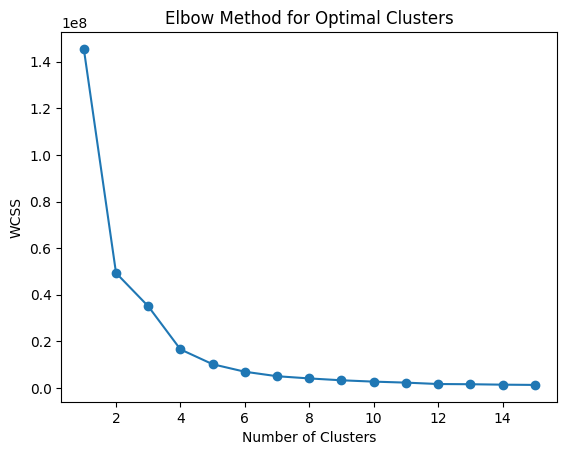

In [ ]:
# 최적 n_clusters 찾기 1번
find_optimal_clusters(X, max_clusters=15)

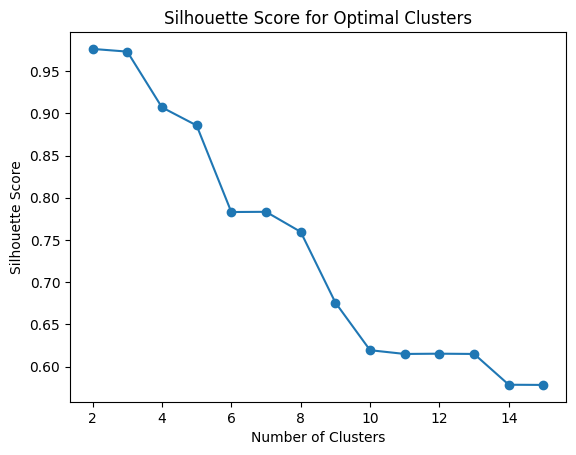

In [ ]:
# 최적 n_clusters 찾기 2번
find_silhouette_scores(X, max_clusters=15)

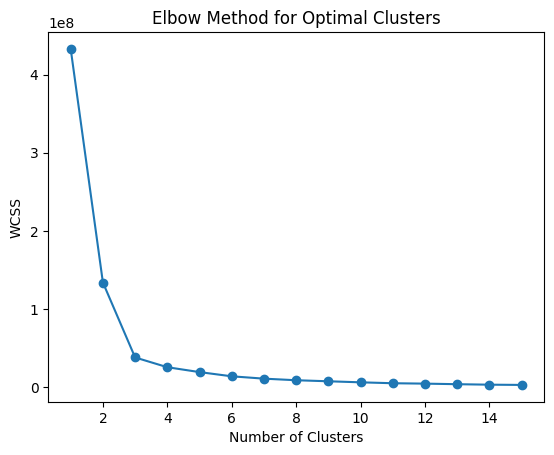

In [ ]:
# 최적 n_clusters 찾기 1번(TEST)
find_optimal_clusters(test_X, max_clusters=15)

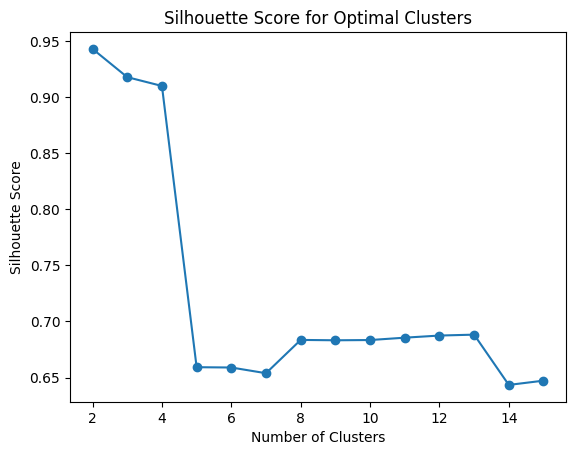

In [ ]:
# 최적 n_clusters 찾기 2번(TEST)
find_silhouette_scores(test_X, max_clusters=15)

In [ ]:
X = add_clustering(X)
test_X = add_clustering(test_X)

<ipython-input-62-b638aa916589>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster'] = kmeans.fit_predict(cluster_features)  # 클러스터 레이블 추가
<ipython-input-62-b638aa916589>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster'] = kmeans.fit_predict(cluster_features)  # 클러스터 레이블 추가


6. 모두 WT인 행인지?

In [ ]:
X['all_wt_row'] = X_all_wt
test_X['all_wt_row'] = test_X_all_wt

<ipython-input-83-d9745e393b1a>:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['all_wt_row'] = X_all_wt
<ipython-input-83-d9745e393b1a>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_X['all_wt_row'] = test_X_all_wt


In [ ]:
X = X.loc[:, ~X.applymap(lambda x: isinstance(x, list)).any()]
test_X = test_X.loc[:, ~test_X.applymap(lambda x: isinstance(x, list)).any()]

<ipython-input-84-74cf69a81622>:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X = X.loc[:, ~X.applymap(lambda x: isinstance(x, list)).any()]
<ipython-input-84-74cf69a81622>:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  test_X = test_X.loc[:, ~test_X.applymap(lambda x: isinstance(x, list)).any()]


아미노산 데이터 클러스터링 최적 찾기

In [ ]:
new_columns = [col for col in X.columns if col.startswith('pre_') or col.startswith('post_')]

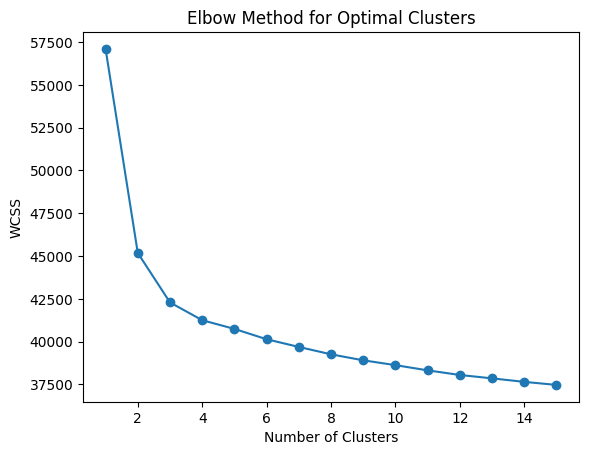

In [ ]:
# 최적 n_clusters 찾기 1번
find_optimal_clusters_aa(X, new_columns, max_clusters=15)

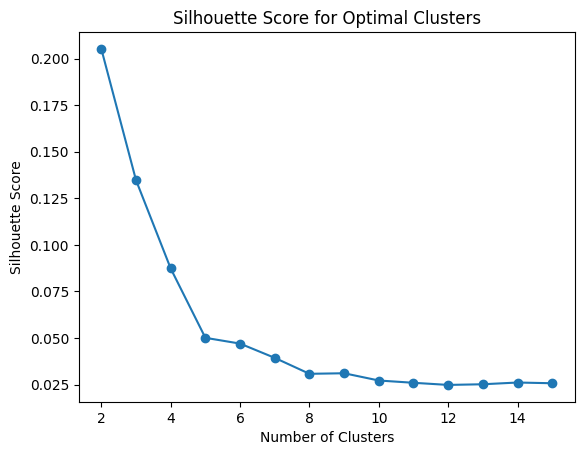

In [ ]:
# 최적 n_clusters 찾기 2번
find_silhouette_scores_aa(X, new_columns, max_clusters=15 )

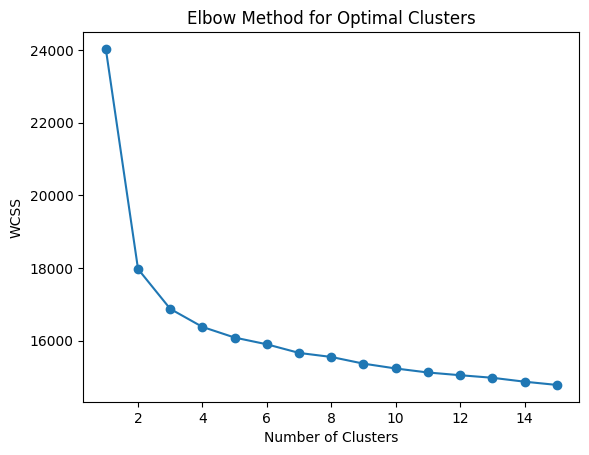

In [ ]:
# 최적 n_clusters 찾기 1번(TEST)
find_optimal_clusters_aa(test_X, new_columns, max_clusters=15)

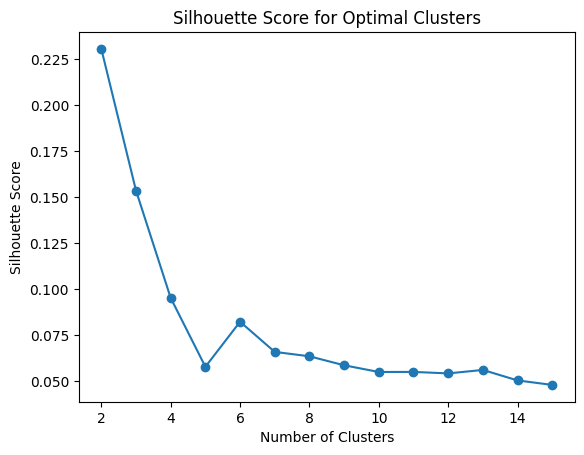

In [ ]:
# 최적 n_clusters 찾기 2번(TEST)
find_silhouette_scores_aa(test_X, new_columns, max_clusters=15)

In [ ]:
X = add_clustering_aa(X)
test_X = add_clustering_aa(test_X)

<ipython-input-63-efc22cefd24b>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_aa'] = kmeans.fit_predict(cluster_features)  # 클러스터 레이블 추가
<ipython-input-63-efc22cefd24b>:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['cluster_aa'] = kmeans.fit_predict(cluster_features)  # 클러스터 레이블 추가


10. top5 위치

In [ ]:
# 상위 5개의 다중 변이 발생 위치 찾기
top_mutation_locations = find_top_multiple_mutation_locations(X.iloc[:, :4384], y_subclass)

# 파생변수 생성 (train과 test에 대해 각각 적용)
X = create_multiple_mutation_columns(X, mutation_columns, top_mutation_locations)
test_X = create_multiple_mutation_columns(test_X, mutation_columns, top_mutation_locations)

<ipython-input-69-a7022fe88f53>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f'{subclass}_multiple_mutation_{i}'] = X.apply(
<ipython-input-69-a7022fe88f53>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f'{subclass}_multiple_mutation_{i}'] = X.apply(
<ipython-input-69-a7022fe88f53>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragment

In [ ]:
top_mutation_locations

{'KIPAN': ['VHL', 'PABPC1', 'TP53', 'HLA-B', 'ABCA4'],
 'SARC': ['AHNAK', 'ATRX', 'RYR2', 'ABI3BP'],
 'SKCM': ['PCLO', 'MXRA5', 'SCN10A', 'MYH4', 'SYNE1'],
 'KIRC': ['ARHGAP5', 'AEBP1', 'ANO1'],
 'GBMLGG': ['EGFR', 'NF1', 'PKHD1'],
 'STES': ['KMT2D'],
 'BRCA': ['PIK3CA', 'MAP3K1', 'DST'],
 'THCA': ['PTEN', 'A2M', 'AAAS', 'AADAT', 'AARS1'],
 'LIHC': ['ALMS1', 'CTNNB1', 'HNF1A'],
 'HNSC': ['COL11A1'],
 'PAAD': ['FLNC', 'GRID2', 'HLA-A', 'KIF1B', 'MAP1B'],
 'OV': ['ACAT1', 'APC', 'CDH13'],
 'PRAD': ['ABCA5', 'ADAM12', 'ADAM2', 'ATP1A1'],
 'UCEC': [],
 'LAML': ['RUNX1', 'CEBPA', 'EZH2', 'KIT'],
 'COAD': ['COL12A1'],
 'ACC': ['LRIG1', 'OGFR', 'PLEC'],
 'LGG': ['NOTCH1'],
 'LUSC': ['SPTA1'],
 'LUAD': [],
 'CESC': ['TEX15', 'MYH9'],
 'PCPG': ['MAL', 'PMM1', 'RET', 'TCAP'],
 'THYM': ['BACH1', 'COL17A1', 'IL12RB1', 'NIPBL'],
 'BLCA': [],
 'TGCT': ['CDC27', 'CDH15', 'COL5A3', 'COL6A3'],
 'DLBC': ['PIM1', 'PDE4DIP', 'BTG1', 'IRF4']}

다중 개수 세기

In [ ]:
# 데이터프레임의 특정 열들(mutation_columns)에 대해 다중 변이 개수를 세기
X['multiple_mutation_count'] = X.apply(lambda row: count_multiple_mutations(row, X.columns[:4384]), axis=1)

# test 데이터에 대해서도 적용
test_X['multiple_mutation_count'] = test_X.apply(lambda row: count_multiple_mutations(row, test_X.columns[:4384]), axis=1)

<ipython-input-92-6012e3d69080>:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X['multiple_mutation_count'] = X.apply(lambda row: count_multiple_mutations(row, X.columns[:4384]), axis=1)
<ipython-input-92-6012e3d69080>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_X['multiple_mutation_count'] = test_X.apply(lambda row: count_multiple_mutations(row, test_X.columns[:4384]), axis=1)


아미노산 개수 세기

In [ ]:
X = add_amino_acid_count_columns(X, mutation_columns)
test_X = add_amino_acid_count_columns(test_X, mutation_columns)

<ipython-input-70-f418a625e40c>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'pre_{aa}_count'] = 0  # 변이 전 아미노산 개수
<ipython-input-70-f418a625e40c>:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'post_{aa}_count'] = 0  # 변이 후 아미노산 개수
<ipython-input-70-f418a625e40c>:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `

Oncogenes, tumor suppressor genes

In [ ]:
oncogenes = ['MRAS', 'EGFR', 'ERBB2', 'BRAF', 'PIK3CA', 'MYC', 'MYCN', 'MET', 'RET', 'FGFR1', 'FGFR3', 'AKT1', 'ERBB3', 'KIT', 'CDK4', 'SRC'] # 대표적인 Oncogenes
tumor_suppressor_genes = ['TP53', 'RB1', 'BRCA1', 'BRCA2', 'PTEN', 'CDKN2A', 'APC', 'VHL', 'MLH1', 'MSH2', 'PMS2', 'NF1', 'NF2', 'TSC1', 'TSC2', 'DCC', 'CHEK2']  # 대표적인 Tumor Suppressor Genes

for gene in oncogenes + tumor_suppressor_genes:
    X[f'{gene}_mutated'] = X[gene].apply(lambda x: 1 if pd.notna(x) and x != 'WT' else 0)
    test_X[f'{gene}_mutated'] = test_X[gene].apply(lambda x: 1 if pd.notna(x) and x != 'WT' else 0)

<ipython-input-94-90f195f7b0fa>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X[f'{gene}_mutated'] = X[gene].apply(lambda x: 1 if pd.notna(x) and x != 'WT' else 0)
<ipython-input-94-90f195f7b0fa>:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_X[f'{gene}_mutated'] = test_X[gene].apply(lambda x: 1 if pd.notna(x) and x != 'WT' else 0)
<ipython-input-94-90f195f7b0fa>:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider

In [ ]:
oncogenes_1 = ['ABL1', 'CCND1', 'NOTCH1', 'CTNNB1', 'NTRK3', 'JAK1', 'JAK2', 'CDK6', 'MDM2', 'CDKN2A', 'GNAS', 'IDH1', 'IDH2', 'PDGFRB', 'ROS1', 'NPM1', 'FOXO1', 'BCL2']  # 대표적인 Oncogenes
tumor_suppressor_genes_1 = ['MST1', 'RUNX1', 'CDH1', 'TGFBR2', 'PTCH1', 'AXIN1', 'BARD1']  # 대표적인 Tumor Suppressor Genes

for gene in oncogenes_1 + tumor_suppressor_genes_1:
    X[f'{gene}_mutated'] = X[gene].apply(lambda x: 1 if pd.notna(x) and x != 'WT' else 0)
    test_X[f'{gene}_mutated'] = test_X[gene].apply(lambda x: 1 if pd.notna(x) and x != 'WT' else 0)

# Modeling

In [ ]:
# SUBCLASS 가 범주형이기 때문에 LabelEncoder 사용
le_subclass = LabelEncoder()
y_subclass = le_subclass.fit_transform(y_subclass)


# 변환된 레이블 확인
for i, label in enumerate(le_subclass.classes_):
    print(f"원래 레이블: {label}, 변환된 숫자: {i}")

원래 레이블: ACC, 변환된 숫자: 0
원래 레이블: BLCA, 변환된 숫자: 1
원래 레이블: BRCA, 변환된 숫자: 2
원래 레이블: CESC, 변환된 숫자: 3
원래 레이블: COAD, 변환된 숫자: 4
원래 레이블: DLBC, 변환된 숫자: 5
원래 레이블: GBMLGG, 변환된 숫자: 6
원래 레이블: HNSC, 변환된 숫자: 7
원래 레이블: KIPAN, 변환된 숫자: 8
원래 레이블: KIRC, 변환된 숫자: 9
원래 레이블: LAML, 변환된 숫자: 10
원래 레이블: LGG, 변환된 숫자: 11
원래 레이블: LIHC, 변환된 숫자: 12
원래 레이블: LUAD, 변환된 숫자: 13
원래 레이블: LUSC, 변환된 숫자: 14
원래 레이블: OV, 변환된 숫자: 15
원래 레이블: PAAD, 변환된 숫자: 16
원래 레이블: PCPG, 변환된 숫자: 17
원래 레이블: PRAD, 변환된 숫자: 18
원래 레이블: SARC, 변환된 숫자: 19
원래 레이블: SKCM, 변환된 숫자: 20
원래 레이블: STES, 변환된 숫자: 21
원래 레이블: TGCT, 변환된 숫자: 22
원래 레이블: THCA, 변환된 숫자: 23
원래 레이블: THYM, 변환된 숫자: 24
원래 레이블: UCEC, 변환된 숫자: 25


In [ ]:
categorical_columns = X.select_dtypes(include=['object', 'category']).columns
ordinal_encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded = X.copy()
X_encoded[categorical_columns] = ordinal_encoder.fit_transform(X[categorical_columns])

In [ ]:
# 모델 적합
model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)
model.fit(X_encoded, y_subclass)

/usr/local/lib/python3.10/dist-packages/xgboost/core.py:158: UserWarning: [06:39:37] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

In [ ]:
X_test_encoded = test_X.copy()
X_test_encoded[categorical_columns] = ordinal_encoder.transform(test_X[categorical_columns])

In [ ]:
# 트레인, 테스트 데이터에서 그룹 예측
predictions = model.predict(X_test_encoded)

In [ ]:
original_labels = le_subclass.inverse_transform(predictions)

In [ ]:
submisson = pd.read_csv("/content/sample_submission.csv")

In [ ]:
submisson["SUBCLASS"] = original_labels

In [ ]:
submisson.to_csv('/content/submission_sy125.csv', encoding='UTF-8-sig', index=False)

# 데이터 저장(실행 X)

In [ ]:
## X와 test_X, y_subclass를 엑셀로 반환
# X.to_csv('/content/drive/MyDrive/DAT/train/[5]X_derived.csv', encoding='UTF-8-sig', index=False)

In [ ]:
# test_X.to_csv('/content/drive/MyDrive/DAT/test/[5]test_X_derived.csv', encoding='UTF-8-sig', index=False)

In [ ]:
X['multiple_mutation_count'].value_counts()

,count
multiple_mutation_count,
0,4558
1,931
2,264
3,103
4,66
...,...
63,1
40,1
270,1
